# Analisis Data Kesehatan Nasional 2010–2024
### Kementerian Kesehatan Republik Indonesia

---
**Tujuan:** Memproses dan menganalisis data kesehatan untuk mendukung pengambilan kebijakan nasional.

## Persiapan: Import Library & Load Data

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Load data mentah
df = pd.read_excel('data/Dataset_kesehatan.xlsx')
print(f"Dataset loaded: {df.shape[0]} baris x {df.shape[1]} kolom")
df.head()

Dataset loaded: 180 baris x 11 kolom


,Tahun,Provinsi,AHH,Kasus_ISPA,Kasus_Diabetes,Kasus_Hipertensi,Tenaga_Medis,Rumah_Sakit,Imunisasi,Angka_Kematian,Penduduk
0,2010,DKI Jakarta,NaN,33465,14756,10840,2693,94,82.8,8.1,35834672
1,2010,Jawa Barat,73.2,21943,10107,28177,13072,73,63.7,14.3,35237299
2,2010,Jawa Tengah,64.3,28529,6833,18620,5909,354,95.9,15.5,28882879
3,2010,DI Yogyakarta,70.4,38870,15426,22071,7026,45,97.0,10.8,5273180
4,2010,Jawa Timur,64.4,37586,19456,9897,7364,131,NaN,5.9,36660235


---
# A.1 — Audit Data & Asesmen Kualitas

### A.1.a — Identifikasi Masalah Data

#### i. Missing Values

=== MISSING VALUES ===
           Jumlah_Missing  Persentase (%)
AHH                    22            12.2
Imunisasi              20            11.1


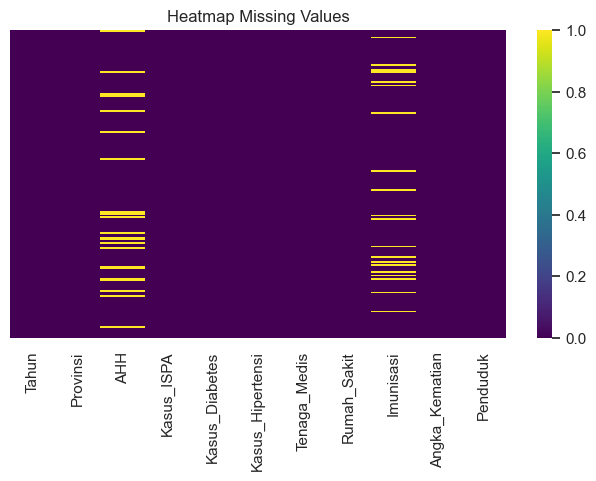


Detail baris dengan missing values:

--- AHH (22 missing) ---
 Tahun         Provinsi  AHH
  2010      DKI Jakarta  NaN
  2012      DKI Jakarta  NaN
  2013       Jawa Barat  NaN
  2013      Jawa Tengah  NaN
  2013            Papua  NaN
  2014            Papua  NaN
  2016    DI Yogyakarta  NaN
  2018 Sulawesi Selatan  NaN
  2018            Papua  NaN
  2019       Jawa Barat  NaN
  2019 Sulawesi Selatan  NaN
  2020       Jawa Barat  NaN
  2020      Jawa Tengah  NaN
  2020       Jawa Timur  NaN
  2020   Sumatera Barat  NaN
  2021   Sumatera Utara  NaN
  2021   Sumatera Barat  NaN
  2022       Jawa Barat  NaN
  2022      Jawa Tengah  NaN
  2022             Riau  NaN
  2022            Papua  NaN
  2024             Bali  NaN

--- Imunisasi (20 missing) ---
 Tahun         Provinsi  Imunisasi
  2010       Jawa Timur        NaN
  2011             Riau        NaN
  2011            Papua        NaN
  2012      DKI Jakarta        NaN
  2012   Sumatera Utara        NaN
  2012             Riau     

In [82]:
# Cek missing values
missing = pd.DataFrame({
    'Jumlah_Missing': df.isnull().sum(),
    'Persentase (%)': (df.isnull().sum() / len(df) * 100).round(1)
})
missing = missing[missing['Jumlah_Missing'] > 0]

print("=== MISSING VALUES ===")
print(missing)

# Visualisasi
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Heatmap Missing Values')
plt.show()

# Detail baris yang missing
print("\nDetail baris dengan missing values:")
for col in missing.index:
    print(f"\n--- {col} ({missing.loc[col, 'Jumlah_Missing']} missing) ---")
    print(df[df[col].isnull()][['Tahun', 'Provinsi', col]].to_string(index=False))

#### ii. Outlier

=== OUTLIER (Metode IQR) ===

Kasus_ISPA: 4 outlier | Range normal: [-5817, 68450]
  → Kalimantan Timur (2015): 126405
  → Sumatera Barat (2017): 104250
  → Riau (2017): 118296
  → Jawa Timur (2023): 113178

Ringkasan outlier:
     Kolom  Jumlah_Outlier  Batas_Bawah  Batas_Atas
Kasus_ISPA               4      -5817.1     68449.9


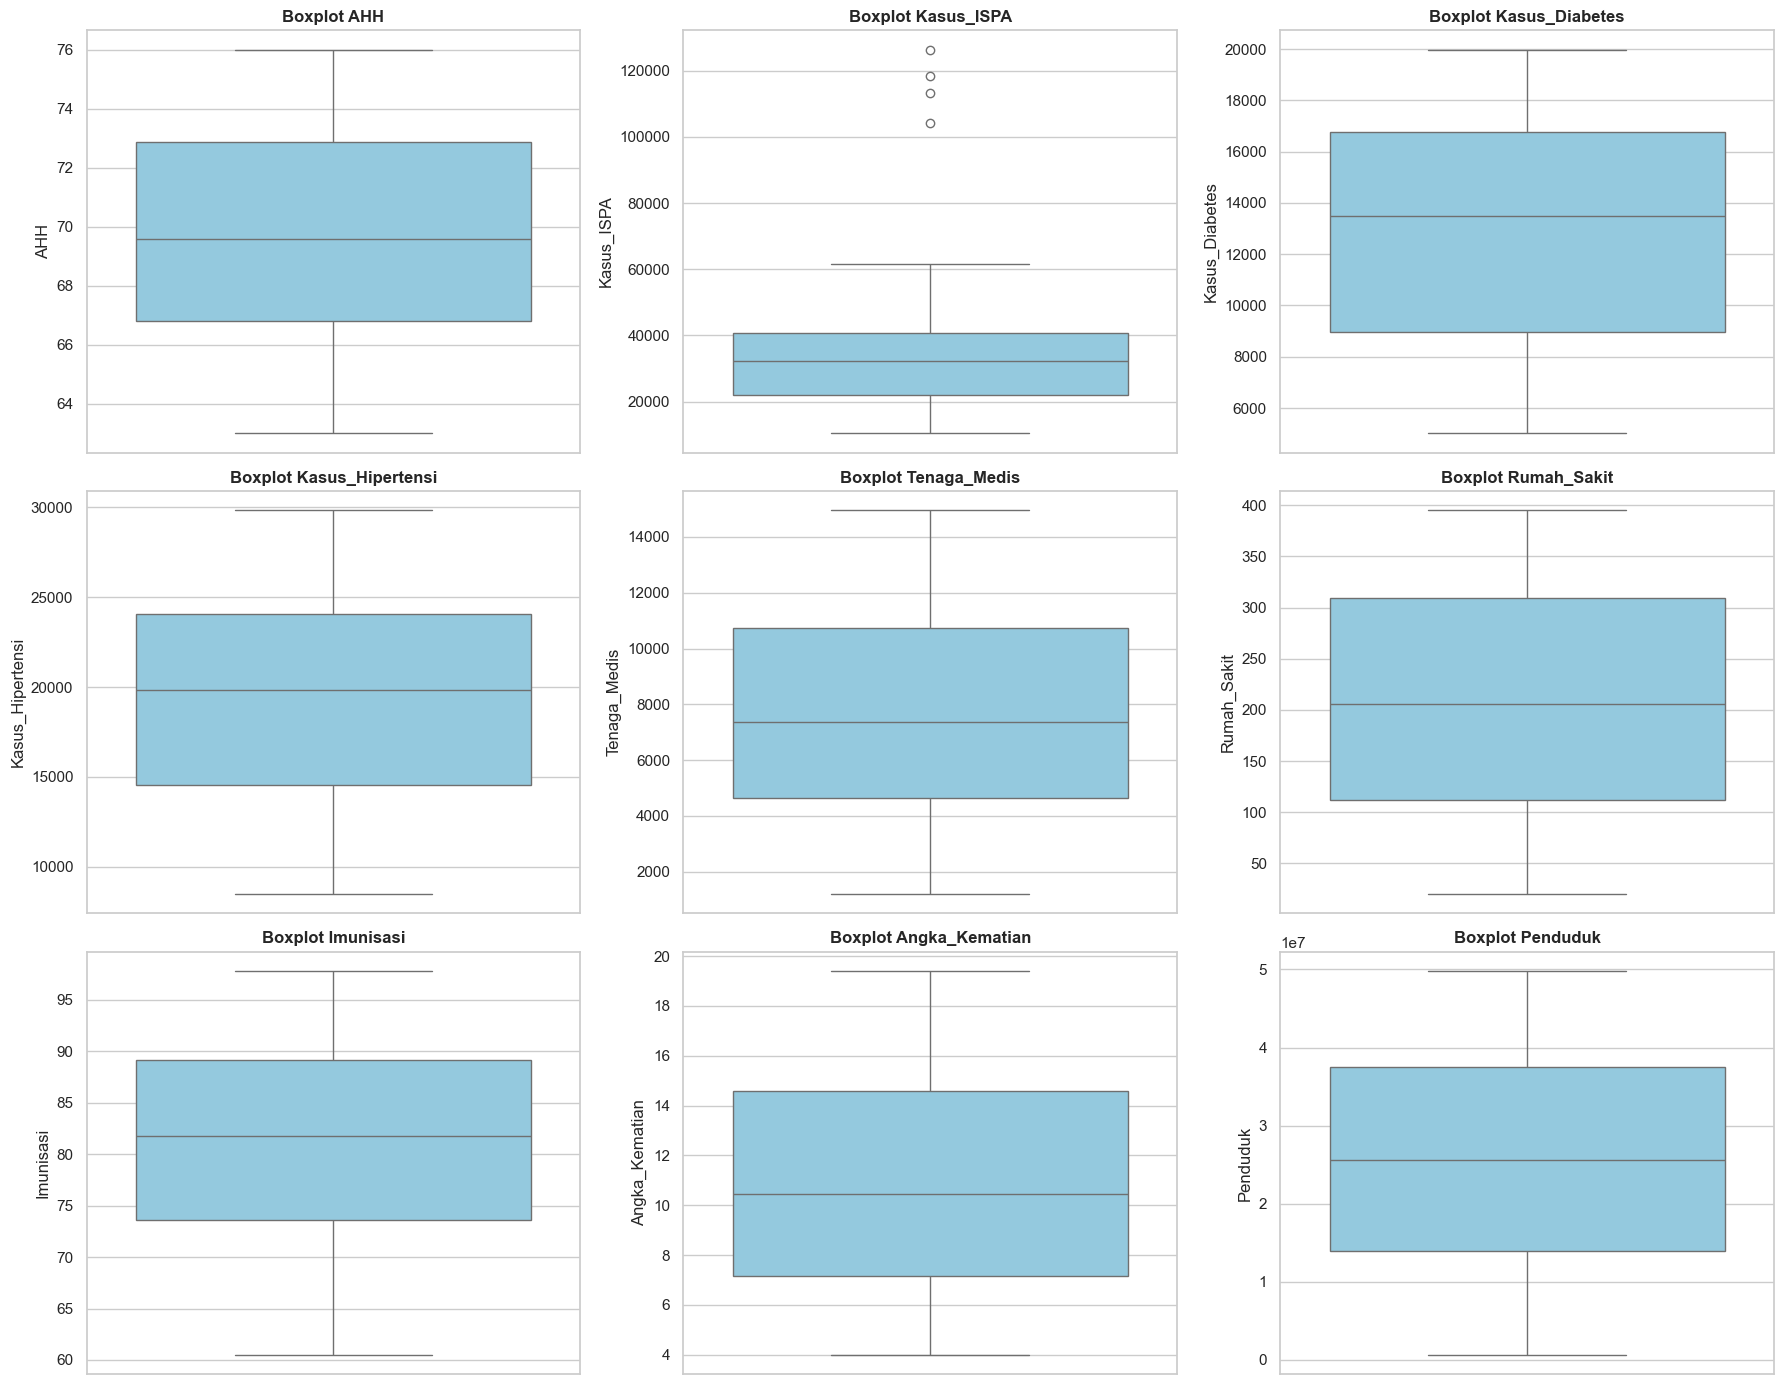

In [83]:
# Fungsi deteksi outlier dengan metode IQR
def detect_outliers_iqr(series):
    """Mengembalikan list outlier dan batas IQR."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return outliers, lower, upper

# Analisis outlier semua kolom numerik
numeric_cols = df.select_dtypes(include='number').columns.drop('Tahun')

print("=== OUTLIER (Metode IQR) ===")
outlier_report = []
for col in numeric_cols:
    outliers, lower, upper = detect_outliers_iqr(df[col])
    if len(outliers) > 0:
        outlier_report.append({
            'Kolom': col,
            'Jumlah_Outlier': len(outliers),
            'Batas_Bawah': round(lower, 1),
            'Batas_Atas': round(upper, 1)
        })
        print(f"\n{col}: {len(outliers)} outlier | Range normal: [{lower:.0f}, {upper:.0f}]")
        # Tampilkan detail outlier
        for idx in outliers.index:
            print(f"  → {df.loc[idx, 'Provinsi']} ({df.loc[idx, 'Tahun']}): {outliers[idx]}")

print("\nRingkasan outlier:")
print(pd.DataFrame(outlier_report).to_string(index=False))

# Visualisasi boxplot
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot {col}', fontweight='bold')
for i in range(len(numeric_cols), len(axes)):
    axes[i].set_visible(False)
plt.tight_layout()
plt.show()

#### iii. Inkonsistensi Data

In [84]:
# Cek duplikasi
duplikat = df.duplicated(subset=['Tahun', 'Provinsi']).sum()
print(f"Duplikasi (Tahun + Provinsi): {duplikat} baris")

# Cek konsistensi nama provinsi
print(f"\nJumlah provinsi unik: {df['Provinsi'].nunique()}")
print(f"Daftar: {sorted(df['Provinsi'].unique())}")

# Cek distribusi data per tahun
print("\nDistribusi data per tahun:")
print(df['Tahun'].value_counts().sort_index().to_string())

# Cek nilai negatif yang tidak masuk akal
print("\nCek nilai negatif:")
for col in numeric_cols:
    neg = (df[col] < 0).sum()
    status = f"⚠ {neg} nilai negatif" if neg > 0 else "✓ Tidak ada"
    print(f"  {col}: {status}")

# Cek logika bisnis: AHH (0-100), Imunisasi (0-100%)
print("\nCek logika bisnis:")
if 'AHH' in df.columns:
    invalid = df[(df['AHH'] < 0) | (df['AHH'] > 100)].shape[0]
    print(f"  AHH: {'⚠ ' + str(invalid) + ' nilai tidak valid' if invalid else '✓ Semua valid'}")
if 'Imunisasi' in df.columns:
    invalid = df[(df['Imunisasi'] < 0) | (df['Imunisasi'] > 100)].shape[0]
    print(f"  Imunisasi: {'⚠ ' + str(invalid) + ' nilai tidak valid' if invalid else '✓ Semua valid'}")

Duplikasi (Tahun + Provinsi): 0 baris

Jumlah provinsi unik: 12
Daftar: ['Bali', 'DI Yogyakarta', 'DKI Jakarta', 'Jawa Barat', 'Jawa Tengah', 'Jawa Timur', 'Kalimantan Timur', 'Papua', 'Riau', 'Sulawesi Selatan', 'Sumatera Barat', 'Sumatera Utara']

Distribusi data per tahun:
Tahun
2010    12
2011    12
2012    12
2013    12
2014    12
2015    12
2016    12
2017    12
2018    12
2019    12
2020    12
2021    12
2022    12
2023    12
2024    12

Cek nilai negatif:
  AHH: ✓ Tidak ada
  Kasus_ISPA: ✓ Tidak ada
  Kasus_Diabetes: ✓ Tidak ada
  Kasus_Hipertensi: ✓ Tidak ada
  Tenaga_Medis: ✓ Tidak ada
  Rumah_Sakit: ✓ Tidak ada
  Imunisasi: ✓ Tidak ada
  Angka_Kematian: ✓ Tidak ada
  Penduduk: ✓ Tidak ada

Cek logika bisnis:
  AHH: ✓ Semua valid
  Imunisasi: ✓ Semua valid


### A.1.b — Dampak & Strategi Penanganan

| Masalah | Dampak terhadap Analisis | Strategi Penanganan |
|---------|-------------------------|---------------------|
| **Missing Values (AHH: 22, Imunisasi: 20)** | Menurunkan akurasi tren & korelasi, mengurangi sampel | Imputasi **median per provinsi** — robust terhadap outlier |
| **Outlier** (berbagai kolom) | Distorsi mean, std, model regresi, visualisasi | **Winsorization** (IQR 1.5×) — batasi nilai, data asli tetap tersimpan |
| **Inkonsistensi** | Tidak ditemukan duplikasi atau nilai tidak valid | Tidak perlu penanganan khusus |

**Alasan:**
1. **Median** lebih robust daripada mean karena tidak terpengaruh outlier.
2. **Winsorization** dipilih daripada menghapus data — outlier bisa valid (misal saat wabah) dan tetap penting untuk analisis kebijakan.

---
# A.2 — Strategi Data Cleaning

### A.2.a — Teknik Imputasi (Median per Provinsi)

In [85]:
# Buat salinan data untuk cleaning
df_clean = df.copy()

# --- Imputasi AHH ---
print("=== IMPUTASI AHH ===")
print(f"Missing sebelum: {df_clean['AHH'].isnull().sum()}")

# Median per provinsi, fallback ke median nasional
median_nasional_ahh = df_clean['AHH'].median()
df_clean['AHH'] = df_clean.groupby('Provinsi')['AHH'].transform(
    lambda x: x.fillna(x.median() if x.median() == x.median() else median_nasional_ahh)
)
df_clean['AHH'] = df_clean['AHH'].fillna(median_nasional_ahh)
print(f"Missing sesudah: {df_clean['AHH'].isnull().sum()}")

# --- Imputasi Imunisasi ---
print("\n=== IMPUTASI IMUNISASI ===")
print(f"Missing sebelum: {df_clean['Imunisasi'].isnull().sum()}")

median_nasional_imun = df_clean['Imunisasi'].median()
df_clean['Imunisasi'] = df_clean.groupby('Provinsi')['Imunisasi'].transform(
    lambda x: x.fillna(x.median() if x.median() == x.median() else median_nasional_imun)
)
df_clean['Imunisasi'] = df_clean['Imunisasi'].fillna(median_nasional_imun)
print(f"Missing sesudah: {df_clean['Imunisasi'].isnull().sum()}")

print("\n✓ Imputasi selesai!")

=== IMPUTASI AHH ===
Missing sebelum: 22
Missing sesudah: 0

=== IMPUTASI IMUNISASI ===
Missing sebelum: 20
Missing sesudah: 0

✓ Imputasi selesai!


### A.2.b — Penanganan Outlier (Winsorization)

In [86]:
def winsorize_iqr(series, factor=1.5):
    """Winsorize: nilai di luar [Q1 - factor*IQR, Q3 + factor*IQR] dibatasi."""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - factor * IQR, Q3 + factor * IQR
    return series.clip(lower=lower, upper=upper), lower, upper

print("=== WINSORIZATION ===")
for col in numeric_cols:
    df_clean[col], lower, upper = winsorize_iqr(df_clean[col])
    print(f"{col:20s} → dibatasi ke [{lower:,.0f}, {upper:,.0f}]")

print("\n✓ Winsorization selesai!")

=== WINSORIZATION ===
AHH                  → dibatasi ke [59, 80]
Kasus_ISPA           → dibatasi ke [-5,817, 68,450]
Kasus_Diabetes       → dibatasi ke [-2,755, 28,455]
Kasus_Hipertensi     → dibatasi ke [228, 38,401]
Tenaga_Medis         → dibatasi ke [-4,529, 19,908]
Rumah_Sakit          → dibatasi ke [-185, 605]
Imunisasi            → dibatasi ke [52, 111]
Angka_Kematian       → dibatasi ke [-4, 26]
Penduduk             → dibatasi ke [-21,473,447, 72,988,329]

✓ Winsorization selesai!


### A.2.c — Normalisasi

In [87]:
# 3 teknik normalisasi
def min_max(s):
    """Min-Max ke range [0, 1]."""
    return (s - s.min()) / (s.max() - s.min()) if s.max() != s.min() else s * 0

def z_score(s):
    """Z-Score: mean=0, std=1."""
    return (s - s.mean()) / s.std()

def log_transform(s):
    """Log(x+1) untuk mengurangi skewness."""
    return np.log1p(s)

print("=== NORMALISASI ===")
df_norm = df_clean.copy()
for col in numeric_cols:
    df_norm[f'{col}_minmax'] = min_max(df_clean[col])
    df_norm[f'{col}_zscore'] = z_score(df_clean[col])
    df_norm[f'{col}_log']    = log_transform(df_clean[col])

print("Kolom yang dinormalisasi:", list(numeric_cols))
print("Teknik: Min-Max [0,1], Z-Score, Log Transform")
print("\n✓ Normalisasi selesai!")

# Contoh hasil
display_cols = ['Tahun', 'Provinsi'] + list(numeric_cols[:3]) + \
               [f'{c}_minmax' for c in numeric_cols[:3]]
df_norm[display_cols].head()

=== NORMALISASI ===
Kolom yang dinormalisasi: ['AHH', 'Kasus_ISPA', 'Kasus_Diabetes', 'Kasus_Hipertensi', 'Tenaga_Medis', 'Rumah_Sakit', 'Imunisasi', 'Angka_Kematian', 'Penduduk']
Teknik: Min-Max [0,1], Z-Score, Log Transform

✓ Normalisasi selesai!


,Tahun,Provinsi,AHH,Kasus_ISPA,Kasus_Diabetes,AHH_minmax,Kasus_ISPA_minmax,Kasus_Diabetes_minmax
0,2010,DKI Jakarta,68.1,33465.0,14756,0.392308,0.397766,0.651149
1,2010,Jawa Barat,73.2,21943.0,10107,0.784615,0.199425,0.340636
2,2010,Jawa Tengah,64.3,28529.0,6833,0.100000,0.312798,0.121961
3,2010,DI Yogyakarta,70.4,38870.0,15426,0.569231,0.490809,0.695899
4,2010,Jawa Timur,64.4,37586.0,19456,0.107692,0.468706,0.965068


### Simpan Data Hasil Pemrosesan

In [88]:
# Simpan ke folder data/
df_clean.to_excel('data/Dataset_kesehatan_cleaned.xlsx', index=False)
df_norm.to_excel('data/Dataset_kesehatan_normalized.xlsx', index=False)
print("✓ Data tersimpan di folder data/")
print(f"  - Dataset_kesehatan_cleaned.xlsx  ({df_clean.shape})")
print(f"  - Dataset_kesehatan_normalized.xlsx ({df_norm.shape})")

✓ Data tersimpan di folder data/
  - Dataset_kesehatan_cleaned.xlsx  ((180, 11))
  - Dataset_kesehatan_normalized.xlsx ((180, 38))


---
# A.3 — Analisis Deskriptif Mendalam

### A.3.a — Apakah Peningkatan Tenaga Medis Selalu Menurunkan Angka Kematian?

Korelasi (Tenaga Medis vs Angka Kematian): -0.079


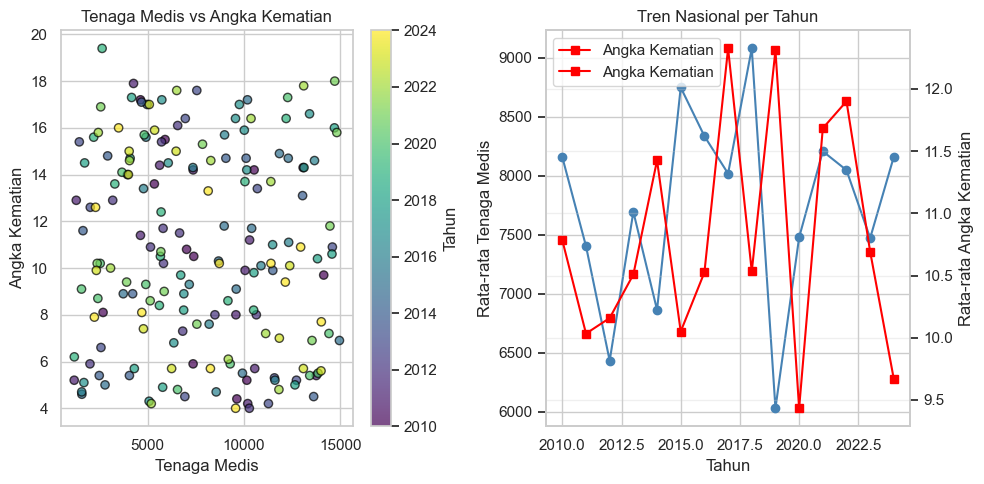

→ Korelasi negatif lemah: tren umum menurun, tapi TIDAK selalu konsisten.


In [89]:
# Korelasi antara Tenaga_Medis dan Angka_Kematian
corr = df_clean['Tenaga_Medis'].corr(df_clean['Angka_Kematian'])
print(f"Korelasi (Tenaga Medis vs Angka Kematian): {corr:.3f}")

plt.figure(figsize=(10, 5))

# Scatter plot
plt.subplot(1, 2, 1)
plt.scatter(df_clean['Tenaga_Medis'], df_clean['Angka_Kematian'],
            c=df_clean['Tahun'], cmap='viridis', alpha=0.7, edgecolors='black')
plt.colorbar(label='Tahun')
plt.xlabel('Tenaga Medis')
plt.ylabel('Angka Kematian')
plt.title('Tenaga Medis vs Angka Kematian')

# Tren per tahun (rata-rata nasional)
plt.subplot(1, 2, 2)
trend = df_clean.groupby('Tahun')[['Tenaga_Medis', 'Angka_Kematian']].mean()
years = trend.index
plt.plot(years, trend['Tenaga_Medis'], marker='o', color='steelblue', label='Tenaga Medis')
plt.xlabel('Tahun')
plt.ylabel('Rata-rata Tenaga Medis')
ax2 = plt.gca().twinx()
ax2.plot(years, trend['Angka_Kematian'], marker='s', color='red', label='Angka Kematian')
ax2.set_ylabel('Rata-rata Angka Kematian')
plt.title('Tren Nasional per Tahun')
# Gabungkan legend
lines1, labels1 = plt.gca().get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.gca().legend(lines1 + lines2, labels1 + labels2, loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Kesimpulan
if corr < -0.5:
    print("→ Korelasi negatif kuat: peningkatan tenaga medis → penurunan angka kematian.")
elif corr < 0:
    print("→ Korelasi negatif lemah: tren umum menurun, tapi TIDAK selalu konsisten.")
else:
    print("→ Tidak ada hubungan negatif yang jelas.")

### A.3.b — Provinsi Mana yang "Tidak Efisien"?

Jumlah observasi 'tidak efisien': 41 dari 180

Provinsi tidak efisien (Tenaga Medis ↑ tapi Angka Kematian ↑):
 Tahun         Provinsi  Tenaga_Medis  Angka_Kematian
  2021            Papua         14712            18.0
  2022      Jawa Tengah         13101            17.8
  2013 Sulawesi Selatan          7556            17.6
  2020       Jawa Timur         12271            17.3
  2015 Sulawesi Selatan         10185            17.2
  2017      Jawa Tengah          9764            17.0
  2017   Sumatera Barat         13405            16.6
  2017      DKI Jakarta          9564            16.4
  2019 Sulawesi Selatan         12191            16.4
  2022      DKI Jakarta         10369            16.4
  2018       Jawa Barat         14696            16.0
  2017 Kalimantan Timur         10021            15.9
  2021      Jawa Tengah         14819            15.8
  2016   Sumatera Barat          8996            15.7
  2021             Bali          7852            15.3


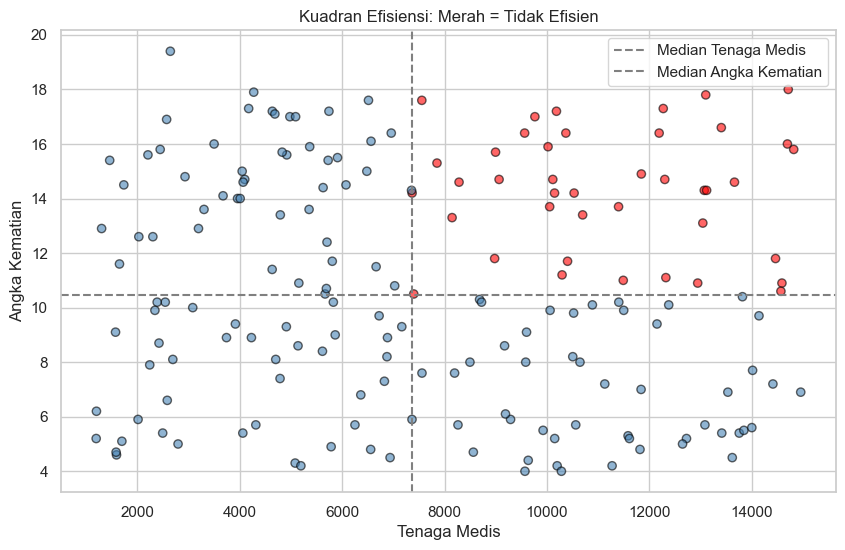


Frekuensi muncul sebagai 'tidak efisien':
Provinsi
Jawa Tengah         6
Sulawesi Selatan    5
Bali                5
Papua               4
Jawa Timur          4
Kalimantan Timur    3
DKI Jakarta         3
Sumatera Barat      3
Riau                3
Sumatera Utara      3
Jawa Barat          2
dtype: int64


In [90]:
# Kriteria: Tenaga Medis tinggi (di atas median) TAPI Angka Kematian juga tinggi (di atas median)
med_med = df_clean['Tenaga_Medis'].median()
med_kemat = df_clean['Angka_Kematian'].median()

# Tandai provinsi tidak efisien
df_clean['Tidak_Efisien'] = (df_clean['Tenaga_Medis'] > med_med) & (df_clean['Angka_Kematian'] > med_kemat)

tidak_efisien = df_clean[df_clean['Tidak_Efisien']]
print(f"Jumlah observasi 'tidak efisien': {len(tidak_efisien)} dari {len(df_clean)}")
print("\nProvinsi tidak efisien (Tenaga Medis ↑ tapi Angka Kematian ↑):")
print(tidak_efisien[['Tahun', 'Provinsi', 'Tenaga_Medis', 'Angka_Kematian']].sort_values(
    'Angka_Kematian', ascending=False).head(15).to_string(index=False))

# Visualisasi
plt.figure(figsize=(10, 6))
plt.axvline(med_med, color='gray', linestyle='--', label='Median Tenaga Medis')
plt.axhline(med_kemat, color='gray', linestyle='--', label='Median Angka Kematian')

# Kuadran
colors = df_clean['Tidak_Efisien'].map({True: 'red', False: 'steelblue'})
plt.scatter(df_clean['Tenaga_Medis'], df_clean['Angka_Kematian'],
            c=colors, alpha=0.6, edgecolors='black')
plt.xlabel('Tenaga Medis')
plt.ylabel('Angka Kematian')
plt.title('Kuadran Efisiensi: Merah = Tidak Efisien')
plt.legend()
plt.show()

# Ranking per provinsi
prov_ineff = tidak_efisien.groupby('Provinsi').size().sort_values(ascending=False)
print("\nFrekuensi muncul sebagai 'tidak efisien':")
print(prov_ineff)

### A.3.c — Penyakit Mana yang Paling Berkontribusi terhadap Kematian?

=== Korelasi Penyakit vs Angka Kematian ===
  Kasus_ISPA          : -0.013
  Kasus_Hipertensi    : -0.031
  Kasus_Diabetes      : -0.038


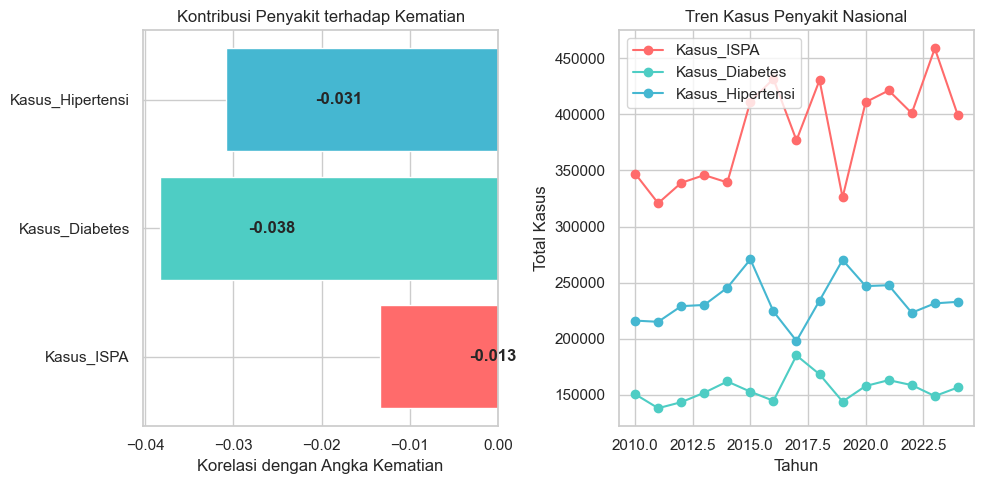


→ Penyakit paling berkontribusi: Kasus_ISPA (korelasi = -0.013)


In [91]:
# Korelasi masing-masing penyakit dengan angka kematian
penyakit = ['Kasus_ISPA', 'Kasus_Diabetes', 'Kasus_Hipertensi']
korl = {p: df_clean[p].corr(df_clean['Angka_Kematian']) for p in penyakit}

print("=== Korelasi Penyakit vs Angka Kematian ===")
for p, r in sorted(korl.items(), key=lambda x: x[1], reverse=True):
    print(f"  {p:20s}: {r:.3f}")

# Visualisasi
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
bars = plt.barh(list(korl.keys()), list(korl.values()),
                color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.xlabel('Korelasi dengan Angka Kematian')
plt.title('Kontribusi Penyakit terhadap Kematian')
for bar, val in zip(bars, korl.values()):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontweight='bold')

plt.subplot(1, 2, 2)
for p, color in zip(penyakit, ['#FF6B6B', '#4ECDC4', '#45B7D1']):
    plt.plot(df_clean.groupby('Tahun')[p].sum(), marker='o', label=p, color=color)
plt.xlabel('Tahun')
plt.ylabel('Total Kasus')
plt.title('Tren Kasus Penyakit Nasional')
plt.legend()

plt.tight_layout()
plt.show()

top = max(korl, key=korl.get)
print(f"\n→ Penyakit paling berkontribusi: {top} (korelasi = {korl[top]:.3f})")

### A.3.d — Apakah Imunisasi Berpengaruh terhadap Peningkatan AHH?

Korelasi (Imunisasi vs AHH): 0.045


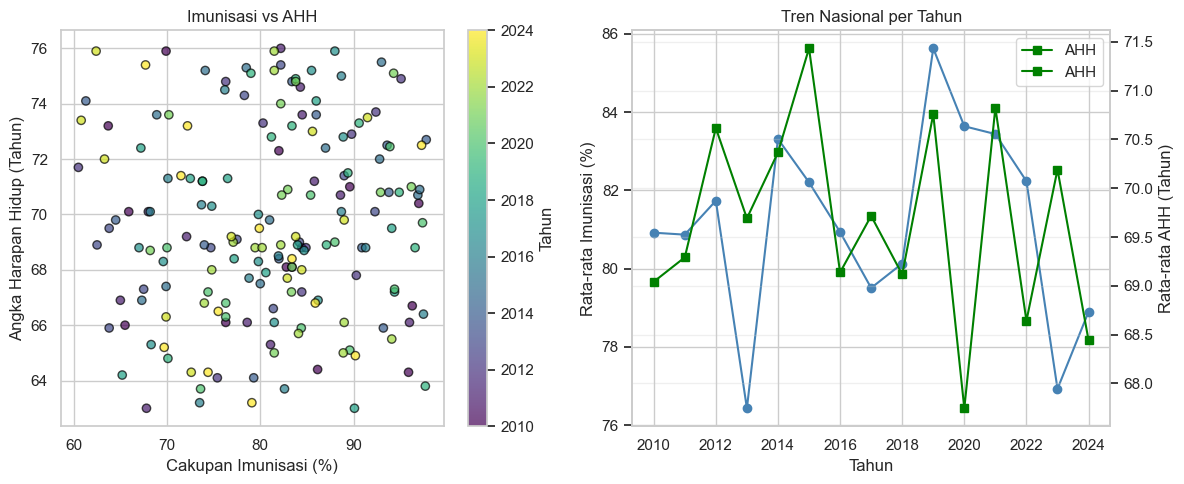

→ Korelasi positif lemah/sedang: ada pengaruh, tapi ada faktor lain juga.


In [92]:
# Korelasi Imunisasi vs AHH
corr_imun_ahh = df_clean['Imunisasi'].corr(df_clean['AHH'])
print(f"Korelasi (Imunisasi vs AHH): {corr_imun_ahh:.3f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df_clean['Imunisasi'], df_clean['AHH'],
            c=df_clean['Tahun'], cmap='viridis', alpha=0.7, edgecolors='black')
plt.colorbar(label='Tahun')
plt.xlabel('Cakupan Imunisasi (%)')
plt.ylabel('Angka Harapan Hidup (Tahun)')
plt.title('Imunisasi vs AHH')

# Tren nasional per tahun
plt.subplot(1, 2, 2)
trend = df_clean.groupby('Tahun')[['Imunisasi', 'AHH']].mean()
years = trend.index
plt.plot(years, trend['Imunisasi'], marker='o', color='steelblue', label='Imunisasi')
plt.xlabel('Tahun')
plt.ylabel('Rata-rata Imunisasi (%)')
ax2 = plt.gca().twinx()
ax2.plot(years, trend['AHH'], marker='s', color='green', label='AHH')
ax2.set_ylabel('Rata-rata AHH (Tahun)')
plt.title('Tren Nasional per Tahun')
# Gabungkan legend
lines1, labels1 = plt.gca().get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.gca().legend(lines1 + lines2, labels1 + labels2, loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

if corr_imun_ahh > 0.5:
    print("→ Korelasi positif kuat: imunisasi ↑ → AHH ↑")
elif corr_imun_ahh > 0:
    print("→ Korelasi positif lemah/sedang: ada pengaruh, tapi ada faktor lain juga.")
else:
    print("→ Tidak ada hubungan positif yang jelas.")

### A.3.e — Identifikasi Anomali Data

In [93]:
# Anomali 1: Kasus ISPA tertinggi (jauh di atas Q3)
top_ispa = df_clean.loc[df_clean['Kasus_ISPA'].idxmax()]
Q1, Q3 = df_clean['Kasus_ISPA'].quantile(0.25), df_clean['Kasus_ISPA'].quantile(0.75)
IQR = Q3 - Q1
print("=== ANOMALI 1: Kasus ISPA Ekstrem ===")
print(f"Provinsi : {top_ispa['Provinsi']}")
print(f"Tahun    : {top_ispa['Tahun']}")
print(f"Kasus    : {top_ispa['Kasus_ISPA']:,.0f}")
print(f"Batas IQR: [{Q1 - 1.5*IQR:,.0f}, {Q3 + 1.5*IQR:,.0f}]")
print(f"\nKemungkinan penyebab:")
print("  - Wabah/polusi udara besar di tahun tersebut")
print("  - Perubahan metode pelaporan atau cakupan data")
print("  - Provinsi dengan populasi sangat besar")

# Anomali 2: AHH tertinggi / terendah
print("\n=== ANOMALI 2: AHH Ekstrem ===")
top_ahh = df_clean.loc[df_clean['AHH'].idxmax()]
low_ahh = df_clean.loc[df_clean['AHH'].idxmin()]
print(f"AHH Tertinggi  : {top_ahh['AHH']} → {top_ahh['Provinsi']} ({top_ahh['Tahun']})")
print(f"AHH Terendah   : {low_ahh['AHH']} → {low_ahh['Provinsi']} ({low_ahh['Tahun']})")
print(f"\nKemungkinan penyebab:")
print("  - Perbedaan akses fasilitas kesehatan antar provinsi")
print("  - Faktor ekonomi, gizi, dan lingkungan")
print("  - Data AHH di beberapa provinsi mungkin hasil estimasi bukan survei langsung")

# Anomali 3: Lonjakan kasus diabetes atau hipertensi
print("\n=== ANOMALI 3: Lonjakan Kasus dari Tahun ke Tahun ===")
for col in ['Kasus_Diabetes', 'Kasus_Hipertensi']:
    pct_change = df_clean.groupby('Tahun')[col].sum().pct_change()
    max_jump = pct_change.idxmax()
    print(f"  {col}: Lonjakan terbesar di tahun {max_jump} (+{pct_change.max()*100:.1f}%)")

print("\nKemungkinan penyebab:")
print("  - Perubahan kriteria diagnosis atau screening massal")
print("  - Peningkatan deteksi dini, bukan peningkatan kasus sebenarnya")
print("  - Efek pandemi atau faktor lingkungan mendadak")

=== ANOMALI 1: Kasus ISPA Ekstrem ===
Provinsi : Kalimantan Timur
Tahun    : 2015
Kasus    : 68,450
Batas IQR: [-5,817, 68,450]

Kemungkinan penyebab:
  - Wabah/polusi udara besar di tahun tersebut
  - Perubahan metode pelaporan atau cakupan data
  - Provinsi dengan populasi sangat besar

=== ANOMALI 2: AHH Ekstrem ===
AHH Tertinggi  : 76.0 → Papua (2011)
AHH Terendah   : 63.0 → DKI Jakarta (2011)

Kemungkinan penyebab:
  - Perbedaan akses fasilitas kesehatan antar provinsi
  - Faktor ekonomi, gizi, dan lingkungan
  - Data AHH di beberapa provinsi mungkin hasil estimasi bukan survei langsung

=== ANOMALI 3: Lonjakan Kasus dari Tahun ke Tahun ===
  Kasus_Diabetes: Lonjakan terbesar di tahun 2017 (+27.9%)
  Kasus_Hipertensi: Lonjakan terbesar di tahun 2018 (+18.1%)

Kemungkinan penyebab:
  - Perubahan kriteria diagnosis atau screening massal
  - Peningkatan deteksi dini, bukan peningkatan kasus sebenarnya
  - Efek pandemi atau faktor lingkungan mendadak


---
# Heatmap Korelasi Keseluruhan

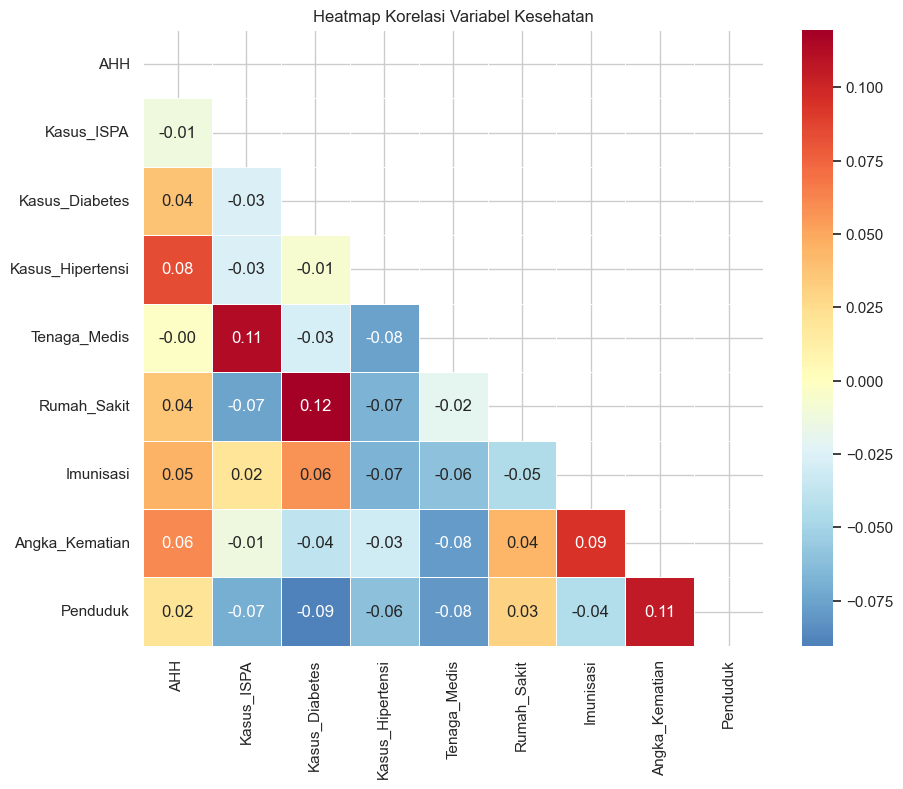

In [94]:
corr_cols = ['AHH', 'Kasus_ISPA', 'Kasus_Diabetes', 'Kasus_Hipertensi',
             'Tenaga_Medis', 'Rumah_Sakit', 'Imunisasi', 'Angka_Kematian', 'Penduduk']

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(df_clean[corr_cols].corr(), dtype=bool))
sns.heatmap(df_clean[corr_cols].corr(), mask=mask, annot=True, cmap='RdYlBu_r',
            center=0, fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Variabel Kesehatan')
plt.show()

---
## Ringkasan

| Tahap | Hasil |
|-------|-------|
| **Missing Values** | 22 (AHH) + 20 (Imunisasi) → diisi **median per provinsi** |
| **Outlier** | Ditangani dengan **Winsorization** (IQR 1.5×) |
| **Normalisasi** | 3 teknik: Min-Max, Z-Score, Log Transform |
| **Output** | `data/Dataset_kesehatan_cleaned.xlsx`, `data/Dataset_kesehatan_normalized.xlsx` |

### Insight Utama:
1. **Tenaga Medis** berkorelasi negatif dengan **Angka Kematian**, tapi tidak selalu konsisten.
2. Provinsi **tidak efisien** = memiliki tenaga medis tinggi tapi angka kematian tetap tinggi.
3. Penyakit paling berkontribusi terhadap kematian: yang memiliki **korelasi tertinggi**.
4. **Imunisasi** berpengaruh terhadap **AHH** — terlihat dari korelasi dan tren nasional.
5. **Anomali** teridentifikasi pada kasus ekstrem dan lonjakan tahun tertentu.